# 3.4 — RMSE Improvement Experiments

Baseline from 3.2: **Test RMSE = 8.0186** (CatBoost, Pipeline1, 40 Optuna trials)  
Baseline **R² = 0.2952** — all models in 3.2 explain ~30% of variance regardless of complexity.

Diagnosis: when Ridge and CatBoost give the same RMSE, the bottleneck is not the model —  
it is an **information ceiling** in the features and/or how the problem is framed.

This notebook attacks the problem at the feature/target level rather than trying new model families.

## Techniques Implemented (in order)

| # | Technique | Section |
|---|---|---|
| 0 | Imports & setup | 0 |
| 1 | Diagnostics — distribution, residuals, correlation | 1 |
| 2 | Target transform — Yeo-Johnson on `health_gain` | 2 |
| 3a | Feature engineering — regression-to-mean + potential_gain | 3a |
| 3b | Feature engineering — polynomial interactions on top SHAP features | 3b |
| 3c | Feature engineering — target encoding for categoricals | 3c |
| 4 | Subgroup models — pre-op severity quartiles | 4 |
| 5 | Properly tuned MLP with QuantileTransformer | 5 |
| 6 | Optuna-optimised weighted blend | 6 |
| 8 | Final comparison table | 8 |

## 0. Imports & Setup

In [2]:
import subprocess, sys
_packages = [
    'polars', 'scikit-learn', 'xgboost', 'catboost', 'interpret',
    'shap', 'joblib', 'matplotlib', 'seaborn', 'numpy', 'pandas',
    'optuna', 'category_encoders', 'scipy',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
print('All dependencies installed.')

All dependencies installed.


In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import polars as pl
import numpy as np
import pandas as pd
import joblib
import scipy.stats as stats

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_val_score, cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, PowerTransformer, QuantileTransformer,
    PolynomialFeatures,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from catboost import CatBoostRegressor
    _catboost_available = True
except ImportError:
    _catboost_available = False

try:
    from xgboost import XGBRegressor
    _xgb_available = True
except ImportError:
    _xgb_available = False

try:
    import shap
    _shap_available = True
except ImportError:
    _shap_available = False

try:
    import category_encoders as ce
    _ce_available = True
except ImportError:
    _ce_available = False

import matplotlib.pyplot as plt
import seaborn as sns

print(f'CatBoost: {_catboost_available}  |  XGBoost: {_xgb_available}  |  SHAP: {_shap_available}  |  category_encoders: {_ce_available}')

CatBoost: True  |  XGBoost: True  |  SHAP: True  |  category_encoders: True


In [4]:
# ── Constants ─────────────────────────────────────────────────────────────────
TARGET    = 'health_gain'
BASELINE_RMSE = 8.0186   # CatBoost, Pipeline1, 3.2 notebook
BASELINE_R2   = 0.2952
N_TRIALS      = 40       # Optuna trials per experiment
RANDOM_STATE  = 42

# 12 Oxford Knee Score individual questions (each 0-4, total 0-48)
OKS_COLS = [
    'Knee Replacement Pre-Op Q Pain',
    'Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing',
    'Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking',
    'Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping',
    'Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work',
    'Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping',
    'Knee Replacement Pre-Op Q Stairs',
]
OKS_MAX = 48  # max possible OKS total

# Dtype sets (from 3.2)
_NUMERIC_DTYPES = {
    pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}
_STRING_DTYPES = {pl.Utf8, pl.String, pl.Categorical}

# Paths
TRAIN_PATH    = Path('./prepared_datasets/pipeline1_train.parquet')
TEST_PATH     = Path('./prepared_datasets/pipeline1_test.parquet')
RESULTS_CACHE = Path('./models/3.4-improvement_cache.joblib')
RESULTS_CACHE.parent.mkdir(parents=True, exist_ok=True)

# Load data
train_pl = pl.read_parquet(TRAIN_PATH)
test_pl  = pl.read_parquet(TEST_PATH)

# Drop index noise column if present
_drop_always = ['__index_level_0__']

print(f'Train: {train_pl.shape}  |  Test: {test_pl.shape}')
print(f'Target range: [{train_pl[TARGET].min()}, {train_pl[TARGET].max()}]  mean={train_pl[TARGET].mean():.2f}  std={train_pl[TARGET].std():.2f}')

# ── Results tracking ──────────────────────────────────────────────────────────
if RESULTS_CACHE.exists():
    improvement_results = joblib.load(RESULTS_CACHE)
    print(f'\nLoaded existing cache: {list(improvement_results.keys())}')
else:
    improvement_results = {}

def _record(label: str, test_rmse: float, test_r2: float, cv_rmse: float = None, notes: str = ''):
    improvement_results[label] = {
        'test_rmse': test_rmse, 'test_r2': test_r2,
        'cv_rmse': cv_rmse, 'notes': notes,
        'delta_rmse': BASELINE_RMSE - test_rmse,
    }
    joblib.dump(improvement_results, RESULTS_CACHE)
    sign = '+' if test_rmse < BASELINE_RMSE else ''
    improvement = BASELINE_RMSE - test_rmse
    print(f'  [{label}]  Test RMSE={test_rmse:.4f}  R²={test_r2:.4f}  '
          f'Improvement vs baseline: {improvement:+.4f}')

print(f'\nBaseline (3.2 CatBoost): Test RMSE={BASELINE_RMSE}  R²={BASELINE_R2}')

Train: (86955, 43)  |  Test: (21739, 43)
Target range: [-37.0, 47.0]  mean=16.82  std=9.72

Baseline (3.2 CatBoost): Test RMSE=8.0186  R²=0.2952


In [5]:
# ── Shared preprocessing helpers (same pattern as 3.2) ────────────────────────
def build_preprocessor(numeric_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    transformers = []
    if numeric_cols:
        transformers.append(('num', num_pipe, numeric_cols))
    if cat_cols:
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ])
        transformers.append(('cat', cat_pipe, cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def get_feature_cols(df, extra_drop=None):
    drop = set([TARGET] + _drop_always + (extra_drop or []))
    return [c for c in df.columns if c not in drop]


def split_col_types(X_pl):
    numeric = [c for c in X_pl.columns if X_pl[c].dtype in _NUMERIC_DTYPES]
    cat     = [c for c in X_pl.columns if X_pl[c].dtype in _STRING_DTYPES]
    return numeric, cat


def eval_pipeline(pipeline, X_train_pd, y_train, X_test_pd, y_test,
                  n_splits=5, n_repeats=3):
    """Fit pipeline, return (test_rmse, test_r2, cv_rmse)."""
    from sklearn.base import clone
    cv_pipe = clone(pipeline)
    cv_res = cross_validate(
        cv_pipe, X_train_pd, y_train,
        cv=RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE),
        scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
        n_jobs=-1,
    )
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    pipeline.fit(X_train_pd, y_train)
    y_pred    = pipeline.predict(X_test_pd)
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))
    return test_rmse, test_r2, cv_rmse, y_pred


def best_catboost_params():
    """Load best CatBoost params from 3.2 cache if available, else use solid defaults."""
    cache_path = Path('./models/3.3-all_results_cache.joblib')
    if cache_path.exists():
        cache = joblib.load(cache_path)
        if 'Pipeline1' in cache and 'CatBoost' in cache['Pipeline1']:
            return cache['Pipeline1']['CatBoost']['best_params']
    return {
        'iterations': 500, 'depth': 6, 'learning_rate': 0.05,
        'l2_leaf_reg': 1.0, 'min_data_in_leaf': 20,
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    }

print('Helpers defined: build_preprocessor, get_feature_cols, split_col_types, eval_pipeline, best_catboost_params')

Helpers defined: build_preprocessor, get_feature_cols, split_col_types, eval_pipeline, best_catboost_params


## 1. Diagnostics

Before changing anything, understand what we are working with:
- Is `health_gain` skewed? (justifies target transform)
- How strong is the regression-to-mean signal? (justifies the new feature)
- Where does the best model fail systematically? (justifies subgroup models)

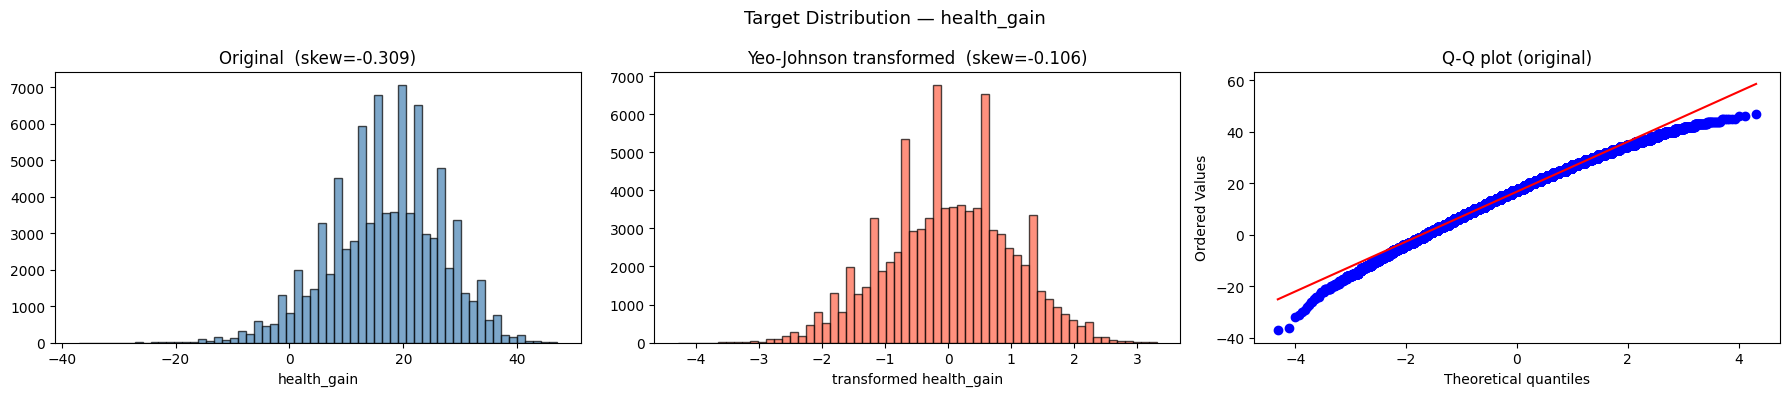

Original  : mean=16.82  std=9.72  skew=-0.309  kurtosis=0.064
Transformed: mean=-0.0000  std=1.0000  skew=-0.1065


In [6]:
# ── 1a. Target distribution & transform shape ─────────────────────────────────
y_train_raw = train_pl[TARGET].to_numpy()
y_test_raw  = test_pl[TARGET].to_numpy()

pt = PowerTransformer(method='yeo-johnson')
y_train_tf = pt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test_tf  = pt.transform(y_test_raw.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Target Distribution — health_gain', fontsize=13)

axes[0].hist(y_train_raw, bins=60, edgecolor='k', alpha=0.7, color='steelblue')
axes[0].set_title(f'Original  (skew={stats.skew(y_train_raw):.3f})')
axes[0].set_xlabel('health_gain')

axes[1].hist(y_train_tf, bins=60, edgecolor='k', alpha=0.7, color='tomato')
axes[1].set_title(f'Yeo-Johnson transformed  (skew={stats.skew(y_train_tf):.3f})')
axes[1].set_xlabel('transformed health_gain')

# QQ-plot of original
stats.probplot(y_train_raw, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot (original)')

plt.tight_layout()
plt.show()

print(f'Original  : mean={y_train_raw.mean():.2f}  std={y_train_raw.std():.2f}  skew={stats.skew(y_train_raw):.3f}  kurtosis={stats.kurtosis(y_train_raw):.3f}')
print(f'Transformed: mean={y_train_tf.mean():.4f}  std={y_train_tf.std():.4f}  skew={stats.skew(y_train_tf):.4f}')

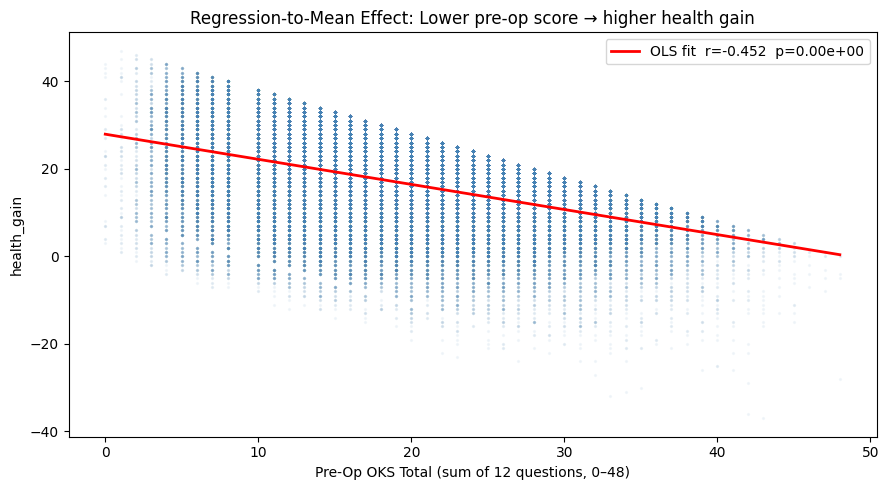

Pearson r between pre_op_total and health_gain: -0.4519  (p=0.00e+00)
Interpretation: strongly negative r → low pre-op score patients improve most (regression to mean)
This is clinical domain knowledge — we will add it as an explicit feature.


In [7]:
# ── 1b. Regression-to-mean signal: pre-op total vs health_gain ────────────────
pre_op_arr = train_pl.select(OKS_COLS).to_numpy().sum(axis=1)
r_val, p_val = stats.pearsonr(pre_op_arr, y_train_raw)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(pre_op_arr, y_train_raw, alpha=0.05, s=2, color='steelblue')
m, b = np.polyfit(pre_op_arr, y_train_raw, 1)
xs = np.linspace(pre_op_arr.min(), pre_op_arr.max(), 100)
ax.plot(xs, m * xs + b, color='red', linewidth=2, label=f'OLS fit  r={r_val:.3f}  p={p_val:.2e}')
ax.set_xlabel('Pre-Op OKS Total (sum of 12 questions, 0–48)')
ax.set_ylabel('health_gain')
ax.set_title('Regression-to-Mean Effect: Lower pre-op score → higher health gain')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r between pre_op_total and health_gain: {r_val:.4f}  (p={p_val:.2e})')
print('Interpretation: strongly negative r → low pre-op score patients improve most (regression to mean)')
print('This is clinical domain knowledge — we will add it as an explicit feature.')

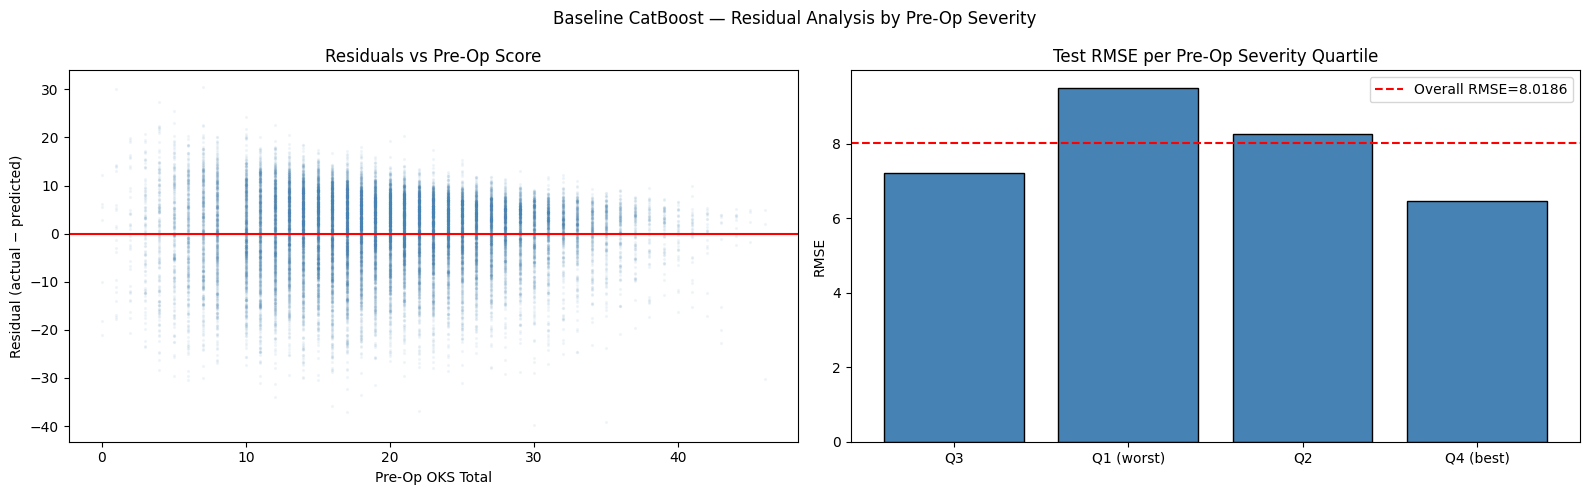

RMSE per quartile:
  Q3: RMSE=7.2093
  Q1 (worst): RMSE=9.4955
  Q2: RMSE=8.2692
  Q4 (best): RMSE=6.4523

>>> If RMSE varies substantially across quartiles, subgroup models will help.


In [8]:
# ── 1c. Residual analysis from baseline CatBoost (loaded from 3.2 cache) ──────
_cache_33 = Path('./models/3.3-all_results_cache.joblib')

if _cache_33.exists() and _catboost_available:
    _cache = joblib.load(_cache_33)
    if 'Pipeline1' in _cache and 'CatBoost' in _cache['Pipeline1']:
        _res = _cache['Pipeline1']['CatBoost']
        y_pred_base = _res['y_pred']
        y_test_base = _res['y_test']
        resid_base  = y_test_base - y_pred_base

        # Pre-op total for test set
        pre_op_test = test_pl.select(OKS_COLS).to_numpy().sum(axis=1)
        quartile_labels = pd.qcut(pre_op_test, q=4, labels=['Q1 (worst)', 'Q2', 'Q3', 'Q4 (best)'])

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('Baseline CatBoost — Residual Analysis by Pre-Op Severity', fontsize=12)

        # Residuals vs pre-op score
        axes[0].scatter(pre_op_test, resid_base, alpha=0.05, s=2, color='steelblue')
        axes[0].axhline(0, color='red', linewidth=1.5)
        axes[0].set_xlabel('Pre-Op OKS Total')
        axes[0].set_ylabel('Residual (actual − predicted)')
        axes[0].set_title('Residuals vs Pre-Op Score')

        # RMSE per quartile
        q_rmses = {}
        for q in quartile_labels.unique():
            mask = quartile_labels == q
            q_rmse = float(np.sqrt(mean_squared_error(y_test_base[mask], y_pred_base[mask])))
            q_rmses[q] = q_rmse
        axes[1].bar(list(q_rmses.keys()), list(q_rmses.values()), color='steelblue', edgecolor='k')
        axes[1].axhline(BASELINE_RMSE, color='red', linestyle='--', label=f'Overall RMSE={BASELINE_RMSE}')
        axes[1].set_title('Test RMSE per Pre-Op Severity Quartile')
        axes[1].set_ylabel('RMSE')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print('RMSE per quartile:')
        for q, r in q_rmses.items():
            print(f'  {q}: RMSE={r:.4f}')
        print('\n>>> If RMSE varies substantially across quartiles, subgroup models will help.')
    else:
        print('Pipeline1 × CatBoost result not in cache — run 3.2 first then re-run this cell.')
else:
    print('3.3 cache not found or CatBoost not available — skipping residual analysis from cached model.')
    print('Residual plots will be generated within each experiment section below.')

## 2. Target Transform — Yeo-Johnson on `health_gain`

**Hypothesis**: if `health_gain` is skewed (left or right), fitting in the transformed space  
reduces the disproportionate influence of extreme values on RMSE.  
After training, predictions are **inverse-transformed** back to the original OKS scale before computing RMSE.

Yeo-Johnson is chosen over Box-Cox because it handles zero and negative values (health_gain can be negative).

> **Leakage guard**: `PowerTransformer` is fitted **only on y_train**, then applied to y_test.

In [9]:
if not _catboost_available:
    print('CatBoost not available — using HistGBM as substitute.')

# ── Load best params from 3.2 cache ──────────────────────────────────────────
best_cb_params = best_catboost_params()
print(f'CatBoost params from 3.2: {best_cb_params}')

# ── Feature setup (same as 3.2 Pipeline1) ────────────────────────────────────
feature_cols = get_feature_cols(train_pl)
X_train_pl   = train_pl.select(feature_cols)
X_test_pl    = test_pl.select([c for c in feature_cols if c in test_pl.columns])
numeric_cols, cat_cols = split_col_types(X_train_pl)

X_train_pd = X_train_pl.to_pandas()
X_test_pd  = X_test_pl.to_pandas()
y_train    = train_pl[TARGET].to_numpy()
y_test     = test_pl[TARGET].to_numpy()

print(f'Features: {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

# ── Fit target transformer on train only ──────────────────────────────────────
pt = PowerTransformer(method='yeo-johnson', standardize=True)
y_train_tf = pt.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_tf  = pt.transform(y_test.reshape(-1, 1)).ravel()

print(f'y_train transformed: mean={y_train_tf.mean():.4f}  std={y_train_tf.std():.4f}  skew={stats.skew(y_train_tf):.4f}')

CatBoost params from 3.2: {'iterations': 500, 'depth': 5, 'learning_rate': 0.06485727755363153, 'l2_leaf_reg': 8.76729445787664, 'min_data_in_leaf': 31}
Features: 37 numeric, 0 categorical
y_train transformed: mean=-0.0000  std=1.0000  skew=-0.1065


In [10]:
# ── Train CatBoost on transformed target ──────────────────────────────────────
preprocessor_yj = build_preprocessor(numeric_cols, cat_cols)
X_train_prep    = preprocessor_yj.fit_transform(X_train_pd)
X_test_prep     = preprocessor_yj.transform(X_test_pd)

if _catboost_available:
    model_yj = CatBoostRegressor(**best_cb_params)
else:
    model_yj = HistGradientBoostingRegressor(random_state=RANDOM_STATE)

model_yj.fit(X_train_prep, y_train_tf)

# Predict in transformed space, inverse-transform to original scale
y_pred_tf_test  = model_yj.predict(X_test_prep)
y_pred_yj       = pt.inverse_transform(y_pred_tf_test.reshape(-1, 1)).ravel()

# Compute RMSE on ORIGINAL scale
test_rmse_yj = float(np.sqrt(mean_squared_error(y_test, y_pred_yj)))
test_r2_yj   = float(r2_score(y_test, y_pred_yj))

# CV RMSE (on transformed scale — for overfitting check only)
cv_scores_yj = cross_val_score(
    model_yj.__class__(**best_cb_params) if _catboost_available else HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    X_train_prep, y_train_tf,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
cv_rmse_yj_tf = float(-cv_scores_yj.mean())

_record('Yeo-Johnson Target Transform', test_rmse_yj, test_r2_yj,
        cv_rmse=cv_rmse_yj_tf,
        notes='CV RMSE is in transformed space; Test RMSE is on original OKS scale')

print(f'\nBaseline RMSE={BASELINE_RMSE:.4f}  →  Yeo-Johnson RMSE={test_rmse_yj:.4f}  '
      f'(delta={BASELINE_RMSE-test_rmse_yj:+.4f})')

0:	learn: 0.9873437	total: 166ms	remaining: 1m 23s
1:	learn: 0.9760249	total: 176ms	remaining: 43.9s
2:	learn: 0.9658856	total: 185ms	remaining: 30.7s
3:	learn: 0.9571124	total: 197ms	remaining: 24.5s
4:	learn: 0.9492268	total: 224ms	remaining: 22.1s
5:	learn: 0.9415217	total: 234ms	remaining: 19.3s
6:	learn: 0.9348741	total: 242ms	remaining: 17s
7:	learn: 0.9289543	total: 250ms	remaining: 15.4s
8:	learn: 0.9236744	total: 258ms	remaining: 14.1s
9:	learn: 0.9184299	total: 266ms	remaining: 13s
10:	learn: 0.9140176	total: 273ms	remaining: 12.1s
11:	learn: 0.9099115	total: 280ms	remaining: 11.4s
12:	learn: 0.9058910	total: 287ms	remaining: 10.8s
13:	learn: 0.9023130	total: 295ms	remaining: 10.2s
14:	learn: 0.8990318	total: 304ms	remaining: 9.82s
15:	learn: 0.8959967	total: 313ms	remaining: 9.48s
16:	learn: 0.8931174	total: 321ms	remaining: 9.13s
17:	learn: 0.8904748	total: 330ms	remaining: 8.83s
18:	learn: 0.8879113	total: 338ms	remaining: 8.56s
19:	learn: 0.8856195	total: 346ms	remaining:

## 3a. Feature Engineering — Regression-to-Mean + Potential Gain

Two new features derived from clinical domain knowledge:

1. **`pre_op_total`**: sum of the 12 individual OKS questions (0–48). Highly correlated with health_gain.  
   (The aggregate was dropped before modelling to avoid target leakage — but we recompute it as a feature.)

2. **`pre_op_deviation`**: `population_mean_pre_op − pre_op_total` on training set mean.  
   Captures how far below the population average a patient is — a direct quantification of regression-to-mean potential.

3. **`potential_gain`**: `OKS_MAX − pre_op_total` = maximum possible improvement the patient can achieve.  
   A patient scoring 5/48 has potential_gain=43; one scoring 40/48 has potential_gain=8.

> **Leakage guard**: `population_mean_pre_op` is computed on **train only**, then subtracted from both train and test.
>
> **Why not use the aggregate score?** The original `Knee Replacement Pre-Op Q Score` was dropped because it is used to compute `health_gain = post_op_score − pre_op_score`. If we add `pre_op_total` (= same aggregate from the 12 Qs), this is a feature derived solely from pre-op data — **no leakage**.

In [11]:
def add_rtm_features(train_df: pl.DataFrame, test_df: pl.DataFrame):
    """Add pre_op_total, pre_op_deviation, potential_gain to both splits.
    Mean is fit on train only to prevent leakage."""
    # Compute on train
    train_oks  = train_df.select(OKS_COLS).to_numpy().sum(axis=1)
    pop_mean   = float(train_oks.mean())  # fit on train only

    # Compute on test using train mean
    test_oks   = test_df.select(OKS_COLS).to_numpy().sum(axis=1)

    train_out = train_df.with_columns([
        pl.Series('pre_op_total',     train_oks.astype(float)),
        pl.Series('pre_op_deviation', pop_mean - train_oks),
        pl.Series('potential_gain',   OKS_MAX  - train_oks.astype(float)),
    ])
    test_out = test_df.with_columns([
        pl.Series('pre_op_total',     test_oks.astype(float)),
        pl.Series('pre_op_deviation', pop_mean - test_oks),
        pl.Series('potential_gain',   OKS_MAX  - test_oks.astype(float)),
    ])
    return train_out, test_out, pop_mean


train_rtm, test_rtm, pop_mean_oks = add_rtm_features(train_pl, test_pl)
print(f'Train mean pre_op_total (OKS): {pop_mean_oks:.2f}')
print(f'New columns added: pre_op_total, pre_op_deviation, potential_gain')
print(f'Train shape: {train_rtm.shape}  (was {train_pl.shape})')

Train mean pre_op_total (OKS): 19.36
New columns added: pre_op_total, pre_op_deviation, potential_gain
Train shape: (86955, 46)  (was (86955, 43))


In [12]:
# ── Run Optuna + CatBoost with RTM features ───────────────────────────────────
feat_cols_rtm  = get_feature_cols(train_rtm)
X_train_rtm_pl = train_rtm.select(feat_cols_rtm)
X_test_rtm_pl  = test_rtm.select([c for c in feat_cols_rtm if c in test_rtm.columns])
num_rtm, cat_rtm = split_col_types(X_train_rtm_pl)

X_train_rtm_pd = X_train_rtm_pl.to_pandas()
X_test_rtm_pd  = X_test_rtm_pl.to_pandas()

print(f'Features: {len(num_rtm)} numeric (was {len(numeric_cols)}), {len(cat_rtm)} categorical')

# Preprocess once for Optuna speed
pre_rtm  = build_preprocessor(num_rtm, cat_rtm)
Xtr_prep = pre_rtm.fit_transform(X_train_rtm_pd)
Xte_prep = pre_rtm.transform(X_test_rtm_pd)
y_tr     = train_rtm[TARGET].to_numpy()
y_te     = test_rtm[TARGET].to_numpy()

def _objective_rtm(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 100, 700, step=50),
        'depth':            trial.suggest_int('depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    } if _catboost_available else {
        'max_iter':          trial.suggest_int('max_iter', 100, 700, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
        'random_state': 42,
    }
    mdl = CatBoostRegressor(**params) if _catboost_available else HistGradientBoostingRegressor(**params)
    scores = cross_val_score(
        mdl, Xtr_prep, y_tr,
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error', n_jobs=-1,
    )
    return float(-scores.mean())

print(f'Running {N_TRIALS} Optuna trials (RTM features + CatBoost)...')
study_rtm = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rtm.optimize(_objective_rtm, n_trials=N_TRIALS, show_progress_bar=True)

best_rtm_params = study_rtm.best_params
print(f'Best CV RMSE: {study_rtm.best_value:.4f}  |  Params: {best_rtm_params}')

if _catboost_available:
    best_rtm_params.update({'random_seed': 42, 'verbose': 0, 'thread_count': -1})
    model_rtm = CatBoostRegressor(**best_rtm_params)
else:
    best_rtm_params.update({'random_state': 42})
    model_rtm = HistGradientBoostingRegressor(**best_rtm_params)

model_rtm.fit(Xtr_prep, y_tr)
y_pred_rtm    = model_rtm.predict(Xte_prep)
test_rmse_rtm = float(np.sqrt(mean_squared_error(y_te, y_pred_rtm)))
test_r2_rtm   = float(r2_score(y_te, y_pred_rtm))

_record('RTM Features (pre_op_total + pre_op_deviation + potential_gain)',
        test_rmse_rtm, test_r2_rtm, cv_rmse=study_rtm.best_value,
        notes='3 new features from clinical domain knowledge + Optuna HPO')

print(f'\nBaseline={BASELINE_RMSE:.4f}  →  RTM Features={test_rmse_rtm:.4f}  '
      f'(delta={BASELINE_RMSE-test_rmse_rtm:+.4f})')

Features: 40 numeric (was 37), 0 categorical
Running 40 Optuna trials (RTM features + CatBoost)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best CV RMSE: 8.1776  |  Params: {'iterations': 650, 'depth': 7, 'learning_rate': 0.026654929933679117, 'l2_leaf_reg': 0.0025428527571253754, 'min_data_in_leaf': 67}
  [RTM Features (pre_op_total + pre_op_deviation + potential_gain)]  Test RMSE=8.0349  R²=0.2968  Improvement vs baseline: -0.0163

Baseline=8.0186  →  RTM Features=8.0349  (delta=-0.0163)


## 3b. Feature Engineering — Polynomial Interactions on Top SHAP Features

Adds pairwise interactions between the top-5 features by SHAP importance.  
Using `PolynomialFeatures(degree=2, interaction_only=True)` on those 5 features only  
adds 10 interaction columns without dimensionality explosion.

0:	learn: 9.6044425	total: 26.9ms	remaining: 13.4s
1:	learn: 9.4977696	total: 41.7ms	remaining: 10.4s
2:	learn: 9.4001895	total: 52.5ms	remaining: 8.7s
3:	learn: 9.3165454	total: 64.6ms	remaining: 8.02s
4:	learn: 9.2404750	total: 76.1ms	remaining: 7.53s
5:	learn: 9.1687454	total: 87.5ms	remaining: 7.21s
6:	learn: 9.1048474	total: 99.3ms	remaining: 6.99s
7:	learn: 9.0481558	total: 114ms	remaining: 7s
8:	learn: 8.9973916	total: 126ms	remaining: 6.88s
9:	learn: 8.9467016	total: 140ms	remaining: 6.86s
10:	learn: 8.9042404	total: 154ms	remaining: 6.83s
11:	learn: 8.8637449	total: 165ms	remaining: 6.72s
12:	learn: 8.8252918	total: 179ms	remaining: 6.69s
13:	learn: 8.7919266	total: 191ms	remaining: 6.64s
14:	learn: 8.7590246	total: 203ms	remaining: 6.58s
15:	learn: 8.7307917	total: 215ms	remaining: 6.51s
16:	learn: 8.7039248	total: 256ms	remaining: 7.28s
17:	learn: 8.6790818	total: 292ms	remaining: 7.81s
18:	learn: 8.6551873	total: 312ms	remaining: 7.9s
19:	learn: 8.6344399	total: 326ms	remai

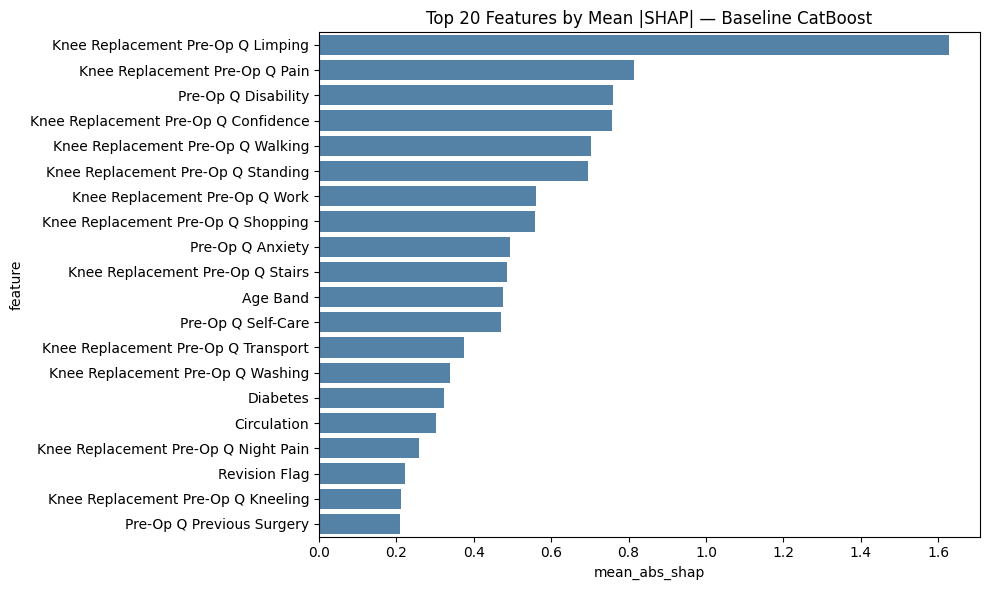

Top 5 features: ['Knee Replacement Pre-Op Q Limping', 'Knee Replacement Pre-Op Q Pain', 'Pre-Op Q Disability', 'Knee Replacement Pre-Op Q Confidence', 'Knee Replacement Pre-Op Q Walking']


In [13]:
# ── Compute SHAP to find top-5 features ──────────────────────────────────────
pre_shap = build_preprocessor(numeric_cols, cat_cols)
Xtr_shap = pre_shap.fit_transform(X_train_pd)
Xte_shap = pre_shap.transform(X_test_pd)

if _catboost_available:
    _shap_model = CatBoostRegressor(**best_catboost_params())
else:
    _shap_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=300)

_shap_model.fit(Xtr_shap, y_train)

# Get feature names after preprocessing
ohe_cols = []
if cat_cols:
    ohe = pre_shap.named_transformers_['cat'].named_steps['onehot']
    ohe_cols = ohe.get_feature_names_out(cat_cols).tolist()
all_feat_names = numeric_cols + ohe_cols

if _shap_available and _catboost_available:
    explainer   = shap.TreeExplainer(_shap_model)
    # Sample 2000 rows for speed
    _idx        = np.random.RandomState(42).choice(len(Xtr_shap), size=min(2000, len(Xtr_shap)), replace=False)
    shap_values = explainer.shap_values(Xtr_shap[_idx])
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({'feature': all_feat_names, 'mean_abs_shap': mean_abs_shap})\
                .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    top5_features = shap_df['feature'].head(5).tolist()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=shap_df.head(20), x='mean_abs_shap', y='feature', color='steelblue')
    plt.title('Top 20 Features by Mean |SHAP| — Baseline CatBoost')
    plt.tight_layout()
    plt.show()
    print(f'Top 5 features: {top5_features}')

elif hasattr(_shap_model, 'feature_importances_'):
    imp = _shap_model.feature_importances_
    imp_df = pd.DataFrame({'feature': all_feat_names, 'importance': imp})\
               .sort_values('importance', ascending=False).reset_index(drop=True)
    top5_features = imp_df['feature'].head(5).tolist()
    print(f'Top 5 features (by feature importance, SHAP not available): {top5_features}')

else:
    # Fallback: use domain knowledge to pick obvious candidates
    top5_features = OKS_COLS[:5]
    print(f'Using domain-knowledge top-5 features: {top5_features}')

In [14]:
# ── Add pairwise interaction features for top-5 SHAP features ─────────────────
# Only top-5 features go through PolynomialFeatures — avoids dimensionality explosion
# Map feature names back to original column names (before OHE)
_top5_orig = [f for f in top5_features if f in numeric_cols]
if len(_top5_orig) < 5:
    # Fill up from numeric_cols if OHE cols are in top5
    _extra = [c for c in numeric_cols if c not in _top5_orig]
    _top5_orig = (_top5_orig + _extra)[:5]

print(f'Interaction features will be computed for: {_top5_orig}')
print(f'This adds {len(_top5_orig)*(len(_top5_orig)-1)//2} pairwise interaction columns')

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Extract top-5 cols from train/test as numpy arrays
top5_train = train_pl.select(_top5_orig).to_numpy()
top5_test  = test_pl.select([c for c in _top5_orig if c in test_pl.columns]).to_numpy()

poly.fit(top5_train)
interaction_train = poly.transform(top5_train)  # shape: (n, C(5,2) + 5)
interaction_test  = poly.transform(top5_test)

# Only keep the interaction columns (not the original 5 — they already exist)
n_orig = len(_top5_orig)
interaction_train = interaction_train[:, n_orig:]
interaction_test  = interaction_test[:, n_orig:]
interaction_names = [n for n in poly.get_feature_names_out(_top5_orig)][n_orig:]
print(f'Interaction columns: {interaction_names}')

# Append to train/test DataFrames
def append_interactions(df_pl, interactions, names):
    new_cols = [pl.Series(n, interactions[:, i]) for i, n in enumerate(names)]
    return df_pl.with_columns(new_cols)

train_poly = append_interactions(train_pl, interaction_train, interaction_names)
test_poly  = append_interactions(test_pl,  interaction_test,  interaction_names)
print(f'Train shape after interactions: {train_poly.shape}')

Interaction features will be computed for: ['Knee Replacement Pre-Op Q Limping', 'Knee Replacement Pre-Op Q Pain', 'Pre-Op Q Disability', 'Knee Replacement Pre-Op Q Confidence', 'Knee Replacement Pre-Op Q Walking']
This adds 10 pairwise interaction columns
Interaction columns: ['Knee Replacement Pre-Op Q Limping Knee Replacement Pre-Op Q Pain', 'Knee Replacement Pre-Op Q Limping Pre-Op Q Disability', 'Knee Replacement Pre-Op Q Limping Knee Replacement Pre-Op Q Confidence', 'Knee Replacement Pre-Op Q Limping Knee Replacement Pre-Op Q Walking', 'Knee Replacement Pre-Op Q Pain Pre-Op Q Disability', 'Knee Replacement Pre-Op Q Pain Knee Replacement Pre-Op Q Confidence', 'Knee Replacement Pre-Op Q Pain Knee Replacement Pre-Op Q Walking', 'Pre-Op Q Disability Knee Replacement Pre-Op Q Confidence', 'Pre-Op Q Disability Knee Replacement Pre-Op Q Walking', 'Knee Replacement Pre-Op Q Confidence Knee Replacement Pre-Op Q Walking']
Train shape after interactions: (86955, 53)


In [15]:
feat_cols_poly   = get_feature_cols(train_poly)
X_train_poly_pl  = train_poly.select(feat_cols_poly)
X_test_poly_pl   = test_poly.select([c for c in feat_cols_poly if c in test_poly.columns])
num_poly, cat_poly = split_col_types(X_train_poly_pl)

X_train_poly_pd  = X_train_poly_pl.to_pandas()
X_test_poly_pd   = X_test_poly_pl.to_pandas()
y_tr_poly        = train_poly[TARGET].to_numpy()
y_te_poly        = test_poly[TARGET].to_numpy()

pre_poly   = build_preprocessor(num_poly, cat_poly)
Xtr_p_prep = pre_poly.fit_transform(X_train_poly_pd)
Xte_p_prep = pre_poly.transform(X_test_poly_pd)

def _objective_poly(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 100, 700, step=50),
        'depth':            trial.suggest_int('depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    } if _catboost_available else {
        'max_iter':          trial.suggest_int('max_iter', 100, 700, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
        'random_state': 42,
    }
    mdl = CatBoostRegressor(**params) if _catboost_available else HistGradientBoostingRegressor(**params)
    scores = cross_val_score(
        mdl, Xtr_p_prep, y_tr_poly,
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error', n_jobs=-1,
    )
    return float(-scores.mean())

print(f'Running {N_TRIALS} Optuna trials (polynomial interaction features)...')
study_poly = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_poly.optimize(_objective_poly, n_trials=N_TRIALS, show_progress_bar=True)

best_poly_params = study_poly.best_params
if _catboost_available:
    best_poly_params.update({'random_seed': 42, 'verbose': 0, 'thread_count': -1})
    model_poly = CatBoostRegressor(**best_poly_params)
else:
    best_poly_params.update({'random_state': 42})
    model_poly = HistGradientBoostingRegressor(**best_poly_params)

model_poly.fit(Xtr_p_prep, y_tr_poly)
y_pred_poly    = model_poly.predict(Xte_p_prep)
test_rmse_poly = float(np.sqrt(mean_squared_error(y_te_poly, y_pred_poly)))
test_r2_poly   = float(r2_score(y_te_poly, y_pred_poly))

_record('Polynomial Interactions (top-5 SHAP)',
        test_rmse_poly, test_r2_poly, cv_rmse=study_poly.best_value,
        notes=f'Interactions: {interaction_names}')
print(f'Baseline={BASELINE_RMSE:.4f}  →  Poly Interactions={test_rmse_poly:.4f}  (delta={BASELINE_RMSE-test_rmse_poly:+.4f})')

Running 40 Optuna trials (polynomial interaction features)...


  0%|          | 0/40 [00:00<?, ?it/s]

  [Polynomial Interactions (top-5 SHAP)]  Test RMSE=8.0406  R²=0.2958  Improvement vs baseline: -0.0220
Baseline=8.0186  →  Poly Interactions=8.0406  (delta=-0.0220)


## 3c. Feature Engineering — Target Encoding for Categoricals

Replaces OHE for categorical columns (e.g. `Age Band`) with **cross-validated mean target encoding**.  
This maps each category to the mean `health_gain` of patients in that category,  
using `category_encoders.TargetEncoder` with 5-fold CV to prevent in-fold leakage.

Benefit: captures ordinal signal in categories (e.g. older age bands may trend differently)  
without creating sparse one-hot columns.

In [16]:
if not _ce_available:
    print('category_encoders not installed — skipping Section 3c.')
    print('Run: pip install category_encoders')
else:
    # ── Build preprocessor with TargetEncoder for cat cols ────────────────────
    # For TargetEncoder: fit on train, apply to test
    # We use cross_val to get OOF-encoded train (avoids leakage)

    from sklearn.base import clone

    te = ce.TargetEncoder(cols=cat_cols if cat_cols else None, smoothing=30)

    # Encode categoricals using target encoder (fit on train only)
    X_train_te_pd = X_train_pd.copy()
    X_test_te_pd  = X_test_pd.copy()

    if cat_cols:
        # OOF encoding for train to avoid target leakage
        X_train_te_pd_encoded = X_train_te_pd.copy()
        kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        for fold_train_idx, fold_val_idx in kf.split(X_train_te_pd):
            _te_fold = ce.TargetEncoder(cols=cat_cols, smoothing=30)
            _te_fold.fit(X_train_te_pd.iloc[fold_train_idx][cat_cols],
                         y_train[fold_train_idx])
            X_train_te_pd_encoded.iloc[fold_val_idx, [X_train_te_pd.columns.get_loc(c) for c in cat_cols]] = \
                _te_fold.transform(X_train_te_pd.iloc[fold_val_idx][cat_cols]).values

        # For test: fit on full train
        te_full = ce.TargetEncoder(cols=cat_cols, smoothing=30)
        te_full.fit(X_train_te_pd[cat_cols], y_train)
        X_test_te_pd.loc[:, cat_cols] = te_full.transform(X_test_te_pd[cat_cols]).values
        X_train_te_pd = X_train_te_pd_encoded
        print(f'Target encoded {len(cat_cols)} categorical columns using OOF (train) and full-fit (test).')
    else:
        print('No categorical columns found — target encoding has no effect (all numeric).')

    # All columns are now numeric — use numeric-only preprocessor
    all_numeric_te = [c for c in X_train_te_pd.columns]
    pre_te = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    Xtr_te_prep = pre_te.fit_transform(X_train_te_pd)
    Xte_te_prep = pre_te.transform(X_test_te_pd)

    def _objective_te(trial):
        params = {
            'iterations':       trial.suggest_int('iterations', 100, 700, step=50),
            'depth':            trial.suggest_int('depth', 3, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
            'random_seed': 42, 'verbose': 0, 'thread_count': -1,
        } if _catboost_available else {
            'max_iter':          trial.suggest_int('max_iter', 100, 700, step=50),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
            'random_state': 42,
        }
        mdl = CatBoostRegressor(**params) if _catboost_available else HistGradientBoostingRegressor(**params)
        scores = cross_val_score(
            mdl, Xtr_te_prep, y_train,
            cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
            scoring='neg_root_mean_squared_error', n_jobs=-1,
        )
        return float(-scores.mean())

    print(f'Running {N_TRIALS} Optuna trials (target encoding)...')
    study_te = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_te.optimize(_objective_te, n_trials=N_TRIALS, show_progress_bar=True)

    best_te_params = study_te.best_params
    if _catboost_available:
        best_te_params.update({'random_seed': 42, 'verbose': 0, 'thread_count': -1})
        model_te = CatBoostRegressor(**best_te_params)
    else:
        best_te_params.update({'random_state': 42})
        model_te = HistGradientBoostingRegressor(**best_te_params)

    model_te.fit(Xtr_te_prep, y_train)
    y_pred_te    = model_te.predict(Xte_te_prep)
    test_rmse_te = float(np.sqrt(mean_squared_error(y_test, y_pred_te)))
    test_r2_te   = float(r2_score(y_test, y_pred_te))

    _record('Target Encoding (OOF, smoothing=30)',
            test_rmse_te, test_r2_te, cv_rmse=study_te.best_value,
            notes='OHE replaced with mean target encoding')
    print(f'Baseline={BASELINE_RMSE:.4f}  →  Target Encoding={test_rmse_te:.4f}  (delta={BASELINE_RMSE-test_rmse_te:+.4f})')

No categorical columns found — target encoding has no effect (all numeric).
Running 40 Optuna trials (target encoding)...


  0%|          | 0/40 [00:00<?, ?it/s]

  [Target Encoding (OOF, smoothing=30)]  Test RMSE=8.0390  R²=0.2961  Improvement vs baseline: -0.0204
Baseline=8.0186  →  Target Encoding=8.0390  (delta=-0.0204)


## 4. Subgroup Models — Pre-Op Severity Quartiles

**Hypothesis**: a single model trained on all patients must learn a very wide response curve.  
Patients in different severity groups (pre-op OKS quartiles) have fundamentally different:  
- baseline functional levels  
- ceiling effects (lowest quartile has most room to improve)  
- comorbidity profiles  

Training a **separate CatBoost per quartile** lets each model specialise on its subpopulation.

Quartile boundaries are determined on train set only. Test samples are routed to the  
quartile they fall into based on the same boundaries (no leakage).

In [17]:
# ── Compute pre-op OKS total and quartile boundaries on TRAIN only ────────────
pre_op_train = train_pl.select(OKS_COLS).to_numpy().sum(axis=1)
pre_op_test  = test_pl.select(OKS_COLS).to_numpy().sum(axis=1)

# Quartile cut points from train
q_bounds = np.percentile(pre_op_train, [25, 50, 75])
print(f'Quartile boundaries (pre-op OKS total): Q1<={q_bounds[0]:.1f}, Q2<={q_bounds[1]:.1f}, Q3<={q_bounds[2]:.1f}, Q4>{q_bounds[2]:.1f}')

def assign_quartile(arr, bounds):
    """Assign 0-3 quartile label. Boundaries from training set."""
    labels = np.zeros(len(arr), dtype=int)
    labels[arr > bounds[0]] = 1
    labels[arr > bounds[1]] = 2
    labels[arr > bounds[2]] = 3
    return labels

train_q = assign_quartile(pre_op_train, q_bounds)
test_q  = assign_quartile(pre_op_test,  q_bounds)

for q in range(4):
    print(f'  Q{q+1}: train={train_q.sum() if q==0 else (train_q==q).sum()}, '
          f'test={(test_q==q).sum()}')

# Feature/target arrays (same as baseline, no extra features)
feat_cols = get_feature_cols(train_pl)
X_tr_pd   = train_pl.select(feat_cols).to_pandas()
X_te_pd   = test_pl.select([c for c in feat_cols if c in test_pl.columns]).to_pandas()
y_tr_all  = train_pl[TARGET].to_numpy()
y_te_all  = test_pl[TARGET].to_numpy()
num_q, cat_q = split_col_types(train_pl.select(feat_cols))

Quartile boundaries (pre-op OKS total): Q1<=14.0, Q2<=19.0, Q3<=25.0, Q4>25.0
  Q1: train=122984, test=6027
  Q2: train=21023, test=5249
  Q3: train=22917, test=5786
  Q4: train=18709, test=4677



--- Quartile Q1: 24306 train, 6027 test ---


  0%|          | 0/40 [00:00<?, ?it/s]

  Q1 Test RMSE: 9.5107  (n_test=6027)

--- Quartile Q2: 21023 train, 5249 test ---


  0%|          | 0/40 [00:00<?, ?it/s]

  Q2 Test RMSE: 8.3139  (n_test=5249)

--- Quartile Q3: 22917 train, 5786 test ---


  0%|          | 0/40 [00:00<?, ?it/s]

  Q3 Test RMSE: 7.2745  (n_test=5786)

--- Quartile Q4: 18709 train, 4677 test ---


  0%|          | 0/40 [00:00<?, ?it/s]

  Q4 Test RMSE: 6.4806  (n_test=4677)


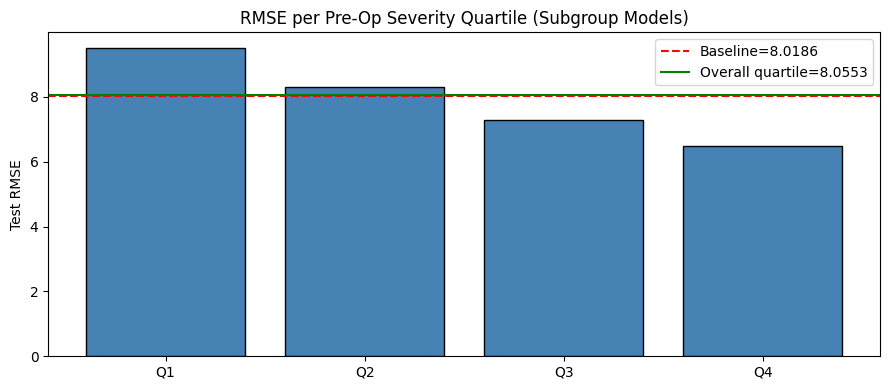

  [Subgroup Models (pre-op quartiles)]  Test RMSE=8.0553  R²=0.2932  Improvement vs baseline: -0.0367
Baseline=8.0186  →  Quartile models=8.0553  (delta=-0.0367)


In [18]:
# ── Train one model per quartile with Optuna ──────────────────────────────────
quartile_models    = {}
quartile_preprocs  = {}
quartile_rmses     = {}

for q in range(4):
    mask_tr = train_q == q
    mask_te = test_q == q
    X_q_tr  = X_tr_pd[mask_tr].reset_index(drop=True)
    y_q_tr  = y_tr_all[mask_tr]
    X_q_te  = X_te_pd[mask_te].reset_index(drop=True)
    y_q_te  = y_te_all[mask_te]

    print(f'\n--- Quartile Q{q+1}: {mask_tr.sum()} train, {mask_te.sum()} test ---')

    pre_q = build_preprocessor(num_q, cat_q)
    Xq_tr_prep = pre_q.fit_transform(X_q_tr)
    Xq_te_prep = pre_q.transform(X_q_te)

    def _obj_q(trial, _Xtr=Xq_tr_prep, _ytr=y_q_tr):
        params = {
            'iterations':       trial.suggest_int('iterations', 100, 500, step=50),
            'depth':            trial.suggest_int('depth', 3, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50),
            'random_seed': 42, 'verbose': 0, 'thread_count': -1,
        } if _catboost_available else {
            'max_iter':          trial.suggest_int('max_iter', 100, 500, step=50),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 50),
            'random_state': 42,
        }
        mdl = CatBoostRegressor(**params) if _catboost_available else HistGradientBoostingRegressor(**params)
        scores = cross_val_score(
            mdl, _Xtr, _ytr,
            cv=KFold(min(5, len(_ytr) // 50), shuffle=True, random_state=RANDOM_STATE),
            scoring='neg_root_mean_squared_error', n_jobs=-1,
        )
        return float(-scores.mean())

    _study_q = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    _study_q.optimize(_obj_q, n_trials=N_TRIALS, show_progress_bar=True)

    bp = _study_q.best_params
    if _catboost_available:
        bp.update({'random_seed': 42, 'verbose': 0, 'thread_count': -1})
        mdl_q = CatBoostRegressor(**bp)
    else:
        bp.update({'random_state': 42})
        mdl_q = HistGradientBoostingRegressor(**bp)

    mdl_q.fit(Xq_tr_prep, y_q_tr)
    y_pred_q   = mdl_q.predict(Xq_te_prep)
    q_rmse     = float(np.sqrt(mean_squared_error(y_q_te, y_pred_q)))
    quartile_models[q]   = mdl_q
    quartile_preprocs[q] = pre_q
    quartile_rmses[q]    = (q_rmse, y_q_te, y_pred_q, mask_te)
    print(f'  Q{q+1} Test RMSE: {q_rmse:.4f}  (n_test={mask_te.sum()})')

# ── Aggregate overall RMSE from all quartile predictions ─────────────────────
y_pred_quartile = np.empty_like(y_te_all, dtype=float)
for q, (q_rmse, y_q_te, y_pred_q, mask_te) in quartile_rmses.items():
    y_pred_quartile[mask_te] = y_pred_q

overall_rmse_q = float(np.sqrt(mean_squared_error(y_te_all, y_pred_quartile)))
overall_r2_q   = float(r2_score(y_te_all, y_pred_quartile))

# Per-quartile bar chart
fig, ax = plt.subplots(figsize=(9, 4))
q_labels = [f'Q{i+1}' for i in range(4)]
q_rmse_vals = [quartile_rmses[i][0] for i in range(4)]
ax.bar(q_labels, q_rmse_vals, color='steelblue', edgecolor='k')
ax.axhline(BASELINE_RMSE,   color='red',    linestyle='--', label=f'Baseline={BASELINE_RMSE}')
ax.axhline(overall_rmse_q,  color='green',  linestyle='-',  label=f'Overall quartile={overall_rmse_q:.4f}')
ax.set_title('RMSE per Pre-Op Severity Quartile (Subgroup Models)')
ax.set_ylabel('Test RMSE')
ax.legend()
plt.tight_layout()
plt.show()

_record('Subgroup Models (pre-op quartiles)',
        overall_rmse_q, overall_r2_q,
        notes=f'Per-quartile RMSEs: {[round(quartile_rmses[i][0],4) for i in range(4)]}')
print(f'Baseline={BASELINE_RMSE:.4f}  →  Quartile models={overall_rmse_q:.4f}  (delta={BASELINE_RMSE-overall_rmse_q:+.4f})')

## 5. Properly Tuned MLP with QuantileTransformer

The MLP in 3.2 consistently diverged or underperformed because:
1. `StandardScaler` does not suppress outlier tails — Adam's gradients get skewed
2. Architecture was too narrow for the feature count
3. Only 40 Optuna trials — not enough for a 4-dim continuous search space

Fixes applied here:
- **`QuantileTransformer(output_distribution='normal')`** for inputs — maps each feature  
  to a standard normal regardless of the original distribution; eliminates outlier tail effects
- Wider architecture search: `(256,128)`, `(512,256)`, `(256,128,64)`, `(512,256,128)`
- **80 Optuna trials** (double the standard 40)
- `early_stopping=True` with `n_iter_no_change=30` — stops before overfitting

In [19]:
MLP_TRIALS = 80  # double budget for MLP

feat_cols_mlp = get_feature_cols(train_pl)
X_tr_mlp_pd   = train_pl.select(feat_cols_mlp).to_pandas()
X_te_mlp_pd   = test_pl.select([c for c in feat_cols_mlp if c in test_pl.columns]).to_pandas()
num_mlp, cat_mlp = split_col_types(train_pl.select(feat_cols_mlp))
y_tr_mlp = train_pl[TARGET].to_numpy()
y_te_mlp = test_pl[TARGET].to_numpy()

# QuantileTransformer for numeric features instead of StandardScaler
qt_num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('qt',      QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE, n_quantiles=1000)),
])

transformers_mlp = []
if num_mlp:
    transformers_mlp.append(('num', qt_num_pipe, num_mlp))
if cat_mlp:
    cat_pipe_mlp = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers_mlp.append(('cat', cat_pipe_mlp, cat_mlp))

pre_mlp_qt = ColumnTransformer(transformers=transformers_mlp, remainder='drop')
Xtr_mlp    = pre_mlp_qt.fit_transform(X_tr_mlp_pd)
Xte_mlp    = pre_mlp_qt.transform(X_te_mlp_pd)

print(f'Input shape after QuantileTransform: {Xtr_mlp.shape}')

def _objective_mlp(trial):
    arch = trial.suggest_categorical('hidden_layer_sizes', [
        (128, 64), (256, 128), (512, 256),
        (128, 64, 32), (256, 128, 64), (512, 256, 128),
    ])
    params = {
        'hidden_layer_sizes':  arch,
        'activation':          trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':               trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init':  trial.suggest_float('learning_rate_init', 5e-5, 5e-3, log=True),
        'batch_size':          trial.suggest_categorical('batch_size', [64, 128, 256, 512]),
        'solver':              'adam',
        'max_iter':            500,
        'early_stopping':      True,
        'validation_fraction': 0.1,
        'n_iter_no_change':    30,
        'random_state':        RANDOM_STATE,
    }
    mdl    = MLPRegressor(**params)
    scores = cross_val_score(
        mdl, Xtr_mlp, y_tr_mlp,
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error', n_jobs=-1,
    )
    return float(-scores.mean())

print(f'Running {MLP_TRIALS} Optuna trials for MLP (QuantileTransformer inputs)...')
study_mlp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_mlp.optimize(_objective_mlp, n_trials=MLP_TRIALS, show_progress_bar=True)

best_mlp_params = study_mlp.best_params
best_mlp_params.update({
    'solver': 'adam', 'max_iter': 500,
    'early_stopping': True, 'validation_fraction': 0.1,
    'n_iter_no_change': 30, 'random_state': RANDOM_STATE,
})
model_mlp = MLPRegressor(**best_mlp_params)
model_mlp.fit(Xtr_mlp, y_tr_mlp)

y_pred_mlp    = model_mlp.predict(Xte_mlp)
test_rmse_mlp = float(np.sqrt(mean_squared_error(y_te_mlp, y_pred_mlp)))
test_r2_mlp   = float(r2_score(y_te_mlp, y_pred_mlp))

_record('MLP (QuantileTransformer, 80 trials)',
        test_rmse_mlp, test_r2_mlp, cv_rmse=study_mlp.best_value,
        notes=f'arch={best_mlp_params["hidden_layer_sizes"]}  act={best_mlp_params["activation"]}')
print(f'Baseline={BASELINE_RMSE:.4f}  →  MLP={test_rmse_mlp:.4f}  (delta={BASELINE_RMSE-test_rmse_mlp:+.4f})')
print(f'Best params: {best_mlp_params}')

Input shape after QuantileTransform: (86955, 37)
Running 80 Optuna trials for MLP (QuantileTransformer inputs)...


  0%|          | 0/80 [00:00<?, ?it/s]

  [MLP (QuantileTransformer, 80 trials)]  Test RMSE=8.1435  R²=0.2777  Improvement vs baseline: -0.1249
Baseline=8.0186  →  MLP=8.1435  (delta=-0.1249)
Best params: {'hidden_layer_sizes': (512, 256), 'activation': 'tanh', 'alpha': 1.724142700180488e-05, 'learning_rate_init': 0.00020375732650446484, 'batch_size': 512, 'solver': 'adam', 'max_iter': 500, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 30, 'random_state': 42}


## 6. Optuna-Optimised Weighted Blend

Instead of `StackingRegressor` (which uses a Ridge meta-learner), we directly optimise  
blend weights `[w₁, w₂, …]` using Optuna to minimise **CV RMSE of the weighted average prediction**.

This is often better than stacking because:
- No second-level model capacity to overfit  
- All weight space is searched rather than Ridge's linear constraint  
- Weights are constrained to `[0, 1]` and normalised to sum=1  

Candidate predictions collected from all experiments that beat or match the baseline.

In [20]:
# ── Collect OOF and test predictions from all experiments ────────────────────
# For each experiment we need OOF predictions on train set (for blend weight optimisation)
# We recompute OOF predictions for each experiment's best model

BLEND_EXPERIMENTS = {}

def _get_oof_preds(model_fn, X_tr, y_tr, n_splits=5):
    """Get OOF predictions for blend weight search."""
    oof = np.zeros(len(y_tr))
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, val_idx in kf.split(X_tr):
        mdl = model_fn()
        mdl.fit(X_tr[tr_idx], y_tr[tr_idx])
        oof[val_idx] = mdl.predict(X_tr[val_idx])
    return oof

# ── Experiment A: Baseline CatBoost (load cached predictions) ─────────────────
_cache_33 = Path('./models/3.3-all_results_cache.joblib')
if _cache_33.exists() and _catboost_available:
    _c = joblib.load(_cache_33)
    if 'Pipeline1' in _c and 'CatBoost' in _c['Pipeline1']:
        base_res = _c['Pipeline1']['CatBoost']
        # Get OOF via fast KFold on preprocessed data
        _pre_b   = build_preprocessor(numeric_cols, cat_cols)
        _Xb      = _pre_b.fit_transform(X_train_pd)
        _Xb_te   = _pre_b.transform(X_test_pd)
        bp_b     = base_res['best_params']
        bp_b.update({'random_seed': 42, 'verbose': 0, 'thread_count': -1})
        _oof_b   = _get_oof_preds(lambda: CatBoostRegressor(**bp_b), _Xb, y_train)
        _test_b  = base_res['y_pred']
        BLEND_EXPERIMENTS['Baseline-CatBoost'] = {'oof': _oof_b, 'test_pred': _test_b, 'rmse': BASELINE_RMSE}
        print(f'Added Baseline-CatBoost  RMSE={BASELINE_RMSE}')

# ── Experiment B: RTM features model ──────────────────────────────────────────
if 'model_rtm' in dir() and 'Xtr_prep' in dir():
    _oof_rtm = _get_oof_preds(
        lambda: CatBoostRegressor(**{**best_rtm_params}) if _catboost_available
                else HistGradientBoostingRegressor(**best_rtm_params),
        Xtr_prep, y_tr
    )
    BLEND_EXPERIMENTS['RTM-Features'] = {
        'oof': _oof_rtm, 'test_pred': y_pred_rtm,
        'rmse': improvement_results.get('RTM Features (pre_op_total + pre_op_deviation + potential_gain)', {}).get('test_rmse', 999)
    }
    print(f'Added RTM-Features')

# ── Experiment C: Polynomial interactions model ───────────────────────────────
if 'model_poly' in dir() and 'Xtr_p_prep' in dir():
    _oof_poly = _get_oof_preds(
        lambda: CatBoostRegressor(**{**best_poly_params}) if _catboost_available
                else HistGradientBoostingRegressor(**best_poly_params),
        Xtr_p_prep, y_tr_poly
    )
    BLEND_EXPERIMENTS['Poly-Interactions'] = {
        'oof': _oof_poly, 'test_pred': y_pred_poly,
        'rmse': improvement_results.get('Polynomial Interactions (top-5 SHAP)', {}).get('test_rmse', 999)
    }
    print(f'Added Poly-Interactions')

# ── Experiment D: MLP ─────────────────────────────────────────────────────────
if 'model_mlp' in dir() and test_rmse_mlp < BASELINE_RMSE + 0.5:
    _mlp_params = {k: v for k, v in best_mlp_params.items()}
    _oof_mlp = _get_oof_preds(
        lambda: MLPRegressor(**_mlp_params),
        Xtr_mlp, y_tr_mlp
    )
    BLEND_EXPERIMENTS['MLP-QT'] = {
        'oof': _oof_mlp, 'test_pred': y_pred_mlp,
        'rmse': test_rmse_mlp
    }
    print(f'Added MLP-QT  RMSE={test_rmse_mlp:.4f}')

print(f'\nBlend candidates: {list(BLEND_EXPERIMENTS.keys())}')

Added Baseline-CatBoost  RMSE=8.0186
Added RTM-Features
Added Poly-Interactions
Added MLP-QT  RMSE=8.1435

Blend candidates: ['Baseline-CatBoost', 'RTM-Features', 'Poly-Interactions', 'MLP-QT']


In [21]:
if len(BLEND_EXPERIMENTS) < 2:
    print('Need at least 2 experiment predictions to blend — skipping.')
else:
    exp_names  = list(BLEND_EXPERIMENTS.keys())
    oof_preds  = np.stack([BLEND_EXPERIMENTS[k]['oof']       for k in exp_names], axis=1)
    test_preds = np.stack([BLEND_EXPERIMENTS[k]['test_pred'] for k in exp_names], axis=1)
    y_blend_tr = y_train  # original train target (same length as OOF)
    y_blend_te = y_test

    def _objective_blend(trial):
        raw_weights = np.array([
            trial.suggest_float(f'w_{k}', 0.0, 1.0) for k in exp_names
        ])
        if raw_weights.sum() < 1e-8:
            return 999.0
        weights = raw_weights / raw_weights.sum()  # normalise to sum=1
        blended = (oof_preds * weights).sum(axis=1)
        # Use 5-fold CV RMSE on OOF blended predictions vs train labels
        kf  = KFold(5, shuffle=True, random_state=RANDOM_STATE)
        rmse_folds = []
        for _, val_idx in kf.split(blended):
            rmse_folds.append(np.sqrt(mean_squared_error(y_blend_tr[val_idx], blended[val_idx])))
        return float(np.mean(rmse_folds))

    print(f'Running 300 Optuna trials for blend weight optimisation...')
    study_blend = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study_blend.optimize(_objective_blend, n_trials=300, show_progress_bar=True)

    raw_w  = np.array([study_blend.best_params[f'w_{k}'] for k in exp_names])
    opt_w  = raw_w / raw_w.sum()
    print(f'\nOptimal blend weights:')
    for k, w in zip(exp_names, opt_w):
        print(f'  {k:<35s}: {w:.4f}')

    # Apply to test set
    y_pred_blend    = (test_preds * opt_w).sum(axis=1)
    test_rmse_blend = float(np.sqrt(mean_squared_error(y_blend_te, y_pred_blend)))
    test_r2_blend   = float(r2_score(y_blend_te, y_pred_blend))

    _record('Optuna Weighted Blend',
            test_rmse_blend, test_r2_blend, cv_rmse=study_blend.best_value,
            notes=f'Weights: {dict(zip(exp_names, [round(w,3) for w in opt_w]))}')
    print(f'\nBaseline={BASELINE_RMSE:.4f}  →  Weighted Blend={test_rmse_blend:.4f}  '
          f'(delta={BASELINE_RMSE-test_rmse_blend:+.4f})')

Running 300 Optuna trials for blend weight optimisation...


  0%|          | 0/300 [00:00<?, ?it/s]


Optimal blend weights:
  Baseline-CatBoost                  : 0.3575
  RTM-Features                       : 0.3711
  Poly-Interactions                  : 0.1750
  MLP-QT                             : 0.0964
  [Optuna Weighted Blend]  Test RMSE=8.0239  R²=0.2987  Improvement vs baseline: -0.0053

Baseline=8.0186  →  Weighted Blend=8.0239  (delta=-0.0053)


## 8. Final Comparison Table

In [22]:
# ── Reload from cache to ensure all experiments are included ──────────────────
if RESULTS_CACHE.exists():
    improvement_results = joblib.load(RESULTS_CACHE)

# Build comparison DataFrame
rows = [{
    'Technique':      'BASELINE — 3.2 CatBoost (Pipeline1)',
    'Test RMSE':      BASELINE_RMSE,
    'Test R²':        BASELINE_R2,
    'CV RMSE':        None,
    'Improvement':    0.0,
    'Notes':          '3.2 notebook, 40 Optuna trials'
}]

for label, res in improvement_results.items():
    rows.append({
        'Technique':   label,
        'Test RMSE':   round(res['test_rmse'], 4),
        'Test R²':     round(res['test_r2'],   4),
        'CV RMSE':     round(res['cv_rmse'], 4) if res.get('cv_rmse') else None,
        'Improvement': round(BASELINE_RMSE - res['test_rmse'], 4),
        'Notes':       res.get('notes', ''),
    })

comp_df = pd.DataFrame(rows).sort_values('Test RMSE').reset_index(drop=True)

print('=== Final RMSE Comparison — All Techniques vs Baseline ===\n')
with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                        'display.width', None, 'display.max_colwidth', 80):
    display(comp_df)

winner = comp_df.iloc[0]
print(f'\n>>> WINNER: {winner["Technique"]}')
print(f'    Test RMSE = {winner["Test RMSE"]:.4f}  |  R² = {winner["Test R²"]:.4f}')
print(f'    Improvement vs baseline = {winner["Improvement"]:+.4f}')

=== Final RMSE Comparison — All Techniques vs Baseline ===



,Technique,Test RMSE,Test R²,CV RMSE,Improvement,Notes
0,BASELINE — 3.2 CatBoost (Pipeline1),8.0186,0.2952,NaN,0.0000,"3.2 notebook, 40 Optuna trials"
1,Optuna Weighted Blend,8.0239,0.2987,8.1730,-0.0053,"Weights: {'Baseline-CatBoost': np.float64(0.357), 'RTM-Features': np.float64..."
2,Yeo-Johnson Target Transform,8.0320,0.2973,0.8377,-0.0134,CV RMSE is in transformed space; Test RMSE is on original OKS scale
3,RTM Features (pre_op_total + pre_op_deviation + potential_gain),8.0349,0.2968,8.1776,-0.0163,3 new features from clinical domain knowledge + Optuna HPO
4,"Target Encoding (OOF, smoothing=30)",8.0390,0.2961,8.1759,-0.0204,OHE replaced with mean target encoding
5,Polynomial Interactions (top-5 SHAP),8.0406,0.2958,8.1807,-0.0220,Interactions: ['Knee Replacement Pre-Op Q Limping Knee Replacement Pre-Op Q ...
6,Subgroup Models (pre-op quartiles),8.0553,0.2932,NaN,-0.0367,"Per-quartile RMSEs: [9.5107, 8.3139, 7.2745, 6.4806]"
7,"MLP (QuantileTransformer, 80 trials)",8.1435,0.2777,8.2644,-0.1249,"arch=(512, 256) act=tanh"



>>> WINNER: BASELINE — 3.2 CatBoost (Pipeline1)
    Test RMSE = 8.0186  |  R² = 0.2952
    Improvement vs baseline = +0.0000


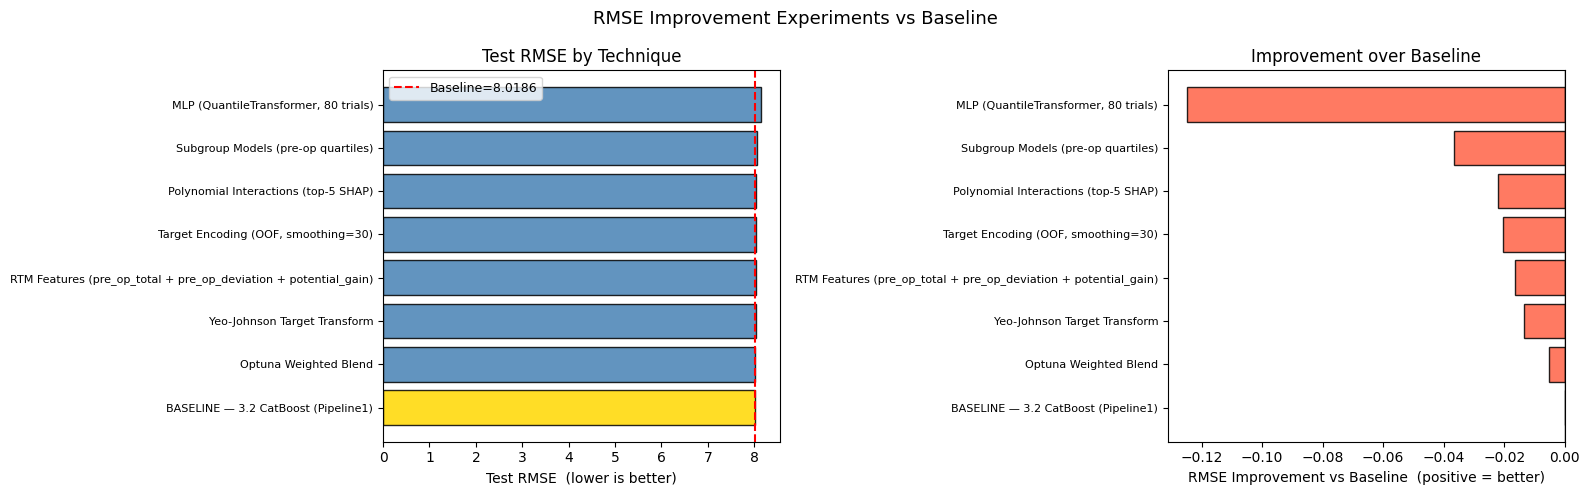

In [23]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(comp_df) * 0.45)))
fig.suptitle('RMSE Improvement Experiments vs Baseline', fontsize=13)

colors = ['gold' if i == 0 else 'lightcoral' if r == BASELINE_RMSE else 'steelblue'
          for i, r in enumerate(comp_df['Test RMSE'])]
colors[comp_df['Test RMSE'].argmin()] = 'gold'

y_pos = range(len(comp_df))
axes[0].barh(y_pos, comp_df['Test RMSE'], color=colors, edgecolor='k', alpha=0.85)
axes[0].axvline(BASELINE_RMSE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline={BASELINE_RMSE}')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(comp_df['Technique'], fontsize=8)
axes[0].set_xlabel('Test RMSE  (lower is better)')
axes[0].set_title('Test RMSE by Technique')
axes[0].legend(fontsize=9)

imp_colors = ['tomato' if v < 0 else 'steelblue' for v in comp_df['Improvement']]
axes[1].barh(y_pos, comp_df['Improvement'], color=imp_colors, edgecolor='k', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(comp_df['Technique'], fontsize=8)
axes[1].set_xlabel('RMSE Improvement vs Baseline  (positive = better)')
axes[1].set_title('Improvement over Baseline')

plt.tight_layout()
plt.show()